# Visualizing Numerical Variables

**Module 2: Data Visualization** | Lean Six Sigma Data Analytics

---

## Two Key Graphs

For numerical variables, the **histogram** and **boxplot** are the most popular visualization methods.

| Graph | Best For |
|-------|----------|
| Histogram | Distribution shape, patterns, symmetry |
| Boxplot | Spread, quartiles, outliers |

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Minitab-style house style -------------------------------------------
import sys
from pathlib import Path as _Path

# minitab_style.py lives in the parent folder of each module directory
sys.path.append(str(_Path.cwd().parent))
import minitab_style as ms

ms.apply_style()

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)
print('Data loaded successfully!')


Data loaded successfully!


---

## Example: Bank Reclaims Processing Time

**Context:** Cross-border money transactions sometimes have errors. When mistakes occur, clients submit reclaims for investigation.

**Question:** What does the distribution of processing times look like?

In [2]:
# Load Reclaims data
reclaims = pd.read_excel(xlsx, sheet_name='Reclaims', skiprows=6, usecols=[0, 1, 2])
reclaims.columns = ['Reclaim_Type', 'Person', 'Processing_Time']
reclaims = reclaims.dropna()

print(f'Dataset: {reclaims.shape[0]} reclaims')
reclaims.head()

Dataset: 122 reclaims


,Reclaim_Type,Person,Processing_Time
0,Account closing,Jan sr.,24.89
1,IBAN,Marcel,27.36
2,Status info,Marcel,2.65
3,Matching,Margriet,23.48
4,Billing,Kees,35.92


---

## Histogram

A histogram gives a quick impression of how a numerical variable is distributed.

### Components

- **Bins:** Vertical bars grouping ranges of values
- **Height:** Represents frequency (count of observations in that range)
- **Horizontal axis:** The variable being measured

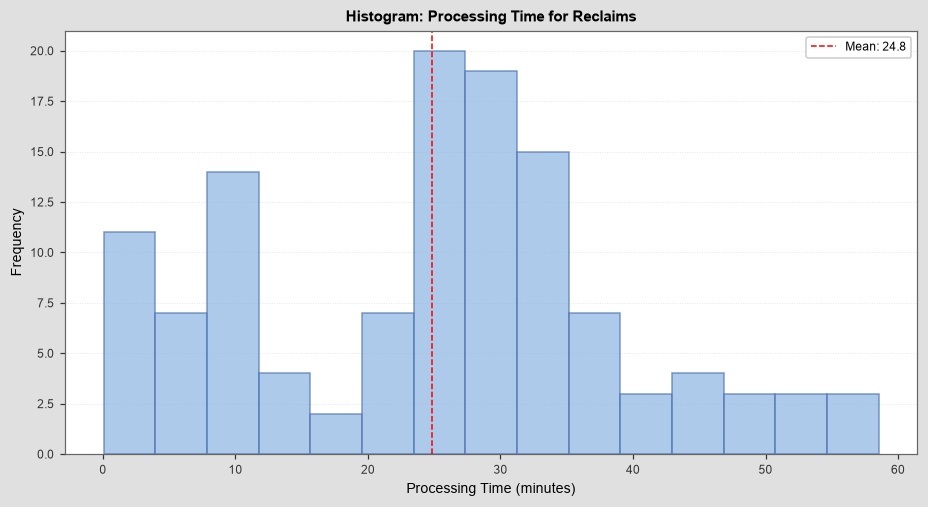

In [3]:
# Histogram - equivalent to Minitab: Graph > Histogram > Simple
plt.figure(figsize=(10, 5))
plt.hist(reclaims['Processing_Time'], bins=15, edgecolor=ms.HIST_EDGE, alpha=0.7, color=ms.HIST_FILL)
plt.xlabel('Processing Time (minutes)')
plt.ylabel('Frequency')
plt.title('Histogram: Processing Time for Reclaims')
plt.axvline(reclaims['Processing_Time'].mean(), color='red', linestyle='--', 
            label=f'Mean: {reclaims["Processing_Time"].mean():.1f}')
plt.legend()
plt.show()

### Reading a Histogram

- **First bin:** Count how many observations fall in the lowest range
- **Decreasing bins:** Larger values become more scarce
- **Total area:** Represents all observations in the dataset

### Patterns to Look For

| Pattern | What It Means |
|---------|---------------|
| **Symmetric** | Data evenly distributed around center |
| **Skewed right** | Long tail to the right; most values clustered left |
| **Skewed left** | Long tail to the left; most values clustered right |
| **Bimodal** | Two peaks; suggests two distinct populations |

In [4]:
# Analyze skewness
skewness = reclaims['Processing_Time'].skew()

print('Skewness Analysis')
print('=' * 40)
print(f'Skewness coefficient: {skewness:.3f}')
print()
if skewness > 0.5:
    print('Distribution is RIGHT-SKEWED (positive skew)')
    print('  - Long tail extends to the right')
    print('  - Most values clustered on the left')
    print('  - Mean > Median')
elif skewness < -0.5:
    print('Distribution is LEFT-SKEWED (negative skew)')
    print('  - Long tail extends to the left')
    print('  - Most values clustered on the right')
    print('  - Mean < Median')
else:
    print('Distribution is approximately SYMMETRIC')
    print('  - Mean ≈ Median')

Skewness Analysis
Skewness coefficient: 0.123

Distribution is approximately SYMMETRIC
  - Mean ≈ Median


---

## Boxplot

A boxplot shows the median, bulk of data (IQR), whiskers, and outliers.

### Components

```
    *           ← Outlier (star)
    |
    |           ← Upper whisker (extends to max within 1.5×IQR)
┌───┴───┐
│       │       ← Box contains middle 50% of data (IQR)
│───────│       ← Median line (50th percentile)
│       │
└───┬───┘
    |           ← Lower whisker
    |
    *           ← Outlier (star)
```

C:\Users\dmnandlu\AppData\Local\Temp\ipykernel_8212\103014307.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(reclaims['Processing_Time'], vert=True)


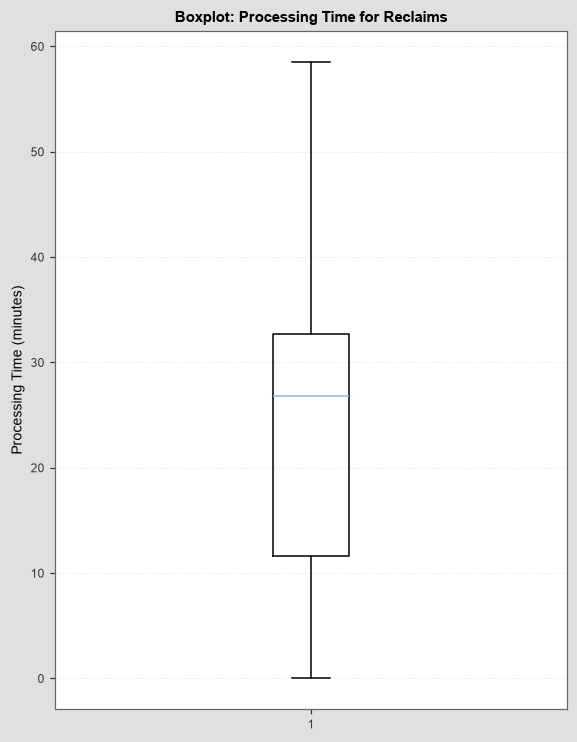

Boxplot Components:
  Median (line in box): 26.8 minutes
  Q1 (bottom of box):   11.6 minutes
  Q3 (top of box):      32.7 minutes
  IQR (box height):     21.1 minutes
  Outlier threshold:    > 64.3 or < -20.0


In [5]:
# Boxplot - equivalent to Minitab: Graph > Boxplot > Simple
plt.figure(figsize=(6, 8))
plt.boxplot(reclaims['Processing_Time'], vert=True)
plt.ylabel('Processing Time (minutes)')
plt.title('Boxplot: Processing Time for Reclaims')
plt.show()

# Extract components
q1 = reclaims['Processing_Time'].quantile(0.25)
median = reclaims['Processing_Time'].median()
q3 = reclaims['Processing_Time'].quantile(0.75)
iqr = q3 - q1

print('Boxplot Components:')
print(f'  Median (line in box): {median:.1f} minutes')
print(f'  Q1 (bottom of box):   {q1:.1f} minutes')
print(f'  Q3 (top of box):      {q3:.1f} minutes')
print(f'  IQR (box height):     {iqr:.1f} minutes')
print(f'  Outlier threshold:    > {q3 + 1.5*iqr:.1f} or < {q1 - 1.5*iqr:.1f}')

### What Each Part Shows

| Component | Meaning |
|-----------|---------|
| **Box** | Middle 50% of data (IQR) |
| **Line in box** | Median (50th percentile) |
| **Bottom of box** | Q1 (25th percentile) |
| **Top of box** | Q3 (75th percentile) |
| **Whiskers** | Extend to min/max within 1.5×IQR |
| **Stars (*)** | Outliers beyond whiskers |

---

## Side-by-Side Comparison

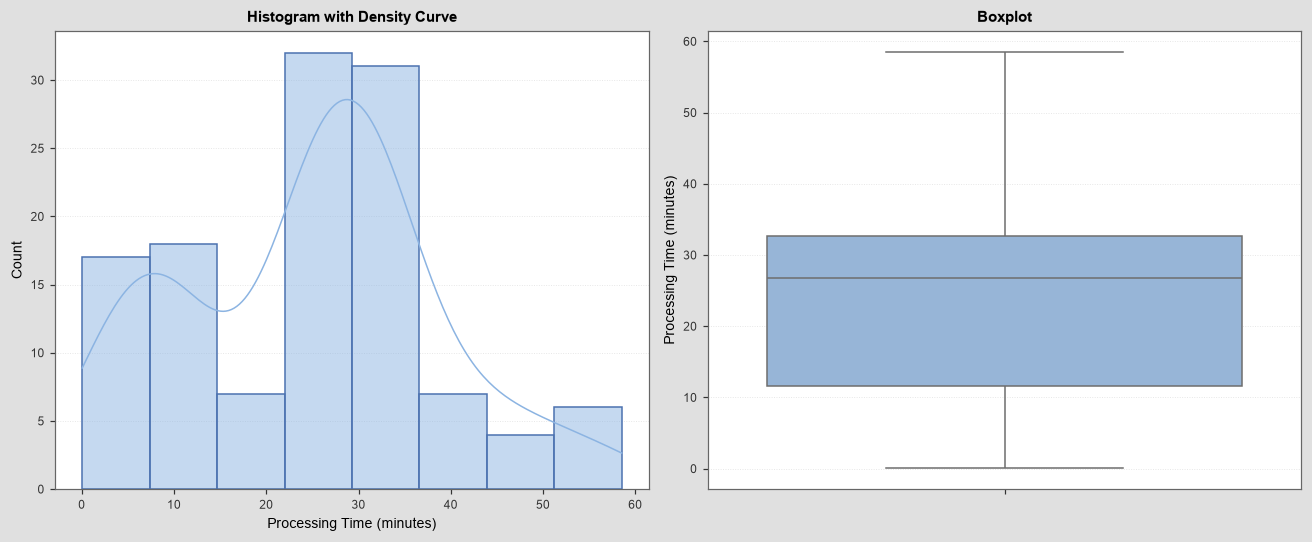

In [6]:
# Combined view with seaborn
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram with KDE (density curve)
sns.histplot(reclaims['Processing_Time'], kde=True, ax=axes[0], color=ms.HIST_FILL)
axes[0].set_xlabel('Processing Time (minutes)')
axes[0].set_title('Histogram with Density Curve')

# Boxplot
sns.boxplot(y=reclaims['Processing_Time'], ax=axes[1], color=ms.HIST_FILL)
axes[1].set_ylabel('Processing Time (minutes)')
axes[1].set_title('Boxplot')

plt.tight_layout()
plt.show()

---

## Histogram vs Boxplot

| Aspect | Histogram | Boxplot |
|--------|-----------|---------|
| Shows distribution shape | Yes (detailed) | Limited |
| Shows outliers | Visible in tails | Explicitly marked with * |
| Shows quartiles | No | Yes (Q1, median, Q3) |
| Shows bimodality | Yes | No |
| Compact display | No | Yes |
| Compare groups | Harder | Easy (side-by-side) |

**Recommendation:** Use both! Histogram for distribution shape, boxplot for summary statistics and outlier detection.

---

## Key Takeaways

- **Histogram:** Shows distribution shape; bins represent frequencies; reveals patterns (symmetric, skewed, bimodal)
- **Boxplot:** Shows median, IQR, whiskers, and outliers; reveals spread and skewness
- Both graphs are for **numerical variables only**
- Use histogram to see the full distribution shape
- Use boxplot to quickly identify median, spread, and outliers